In [22]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import grain.python as pygrain
import tiktoken

import optax

from helper import MadLLM, load_and_preprocess_data, generate_text

In [23]:
# Initialize model parameters
maxlen=128
tokenizer = tiktoken.get_encoding("gpt2")

# Load and preprocess the dataset
text_dl, batches_per_epoch = load_and_preprocess_data(
    file_path='TinyStories-10000.txt',
    batch_size=16,
    maxlen=64,
    max_stories=10000,
    shuffle=True,
    seed=42
)

Loading data from TinyStories-10000.txt (max 10,000 stories)
Loaded 10,000 stories
Estimated batches per epoch: 625
Created DataLoader with batch_size=16, maxlen=64


In [24]:
# Initialize the model
import importlib
import helper
importlib.reload(helper)

model = helper.MadLLM(maxlen = helper.maxlen, 
               vocab_size=helper.vocab_size,
               embed_dim=helper.embed_dim,
               num_heads=helper.num_heads,
               feed_forward_dim=helper.feed_forward_dim,
               num_transformer_blocks=helper.num_transformer_blocks,
               rngs=nnx.Rngs(0)
               )

In [25]:
# Define the loss function
def loss_fn(model, batch):
    inputs, targets = batch
    logits = model(inputs)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits, targets
    ).mean()
    return loss, logits

#parameters for training
num_epochs=3
total_steps = batches_per_epoch * num_epochs
warmup_steps = max(1, total_steps // 10)  # 10% warmup
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

# Define the learning rate schedule
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-5
)

Total training steps: 1,875
Warmup steps: 187


In [26]:
# Create the optimizer
optimizer = nnx.Optimizer(
    model,
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.01),
    wrt=nnx.Param
)

# Define metrics
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
)

In [27]:
# Training step function
@nnx.jit
def train_step(model, optimizer, metrics, batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=batch[1])
    optimizer.update(model, grads)

In [28]:
#running the training loop
metrics_history = {'train_loss': []}

prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0]))))

for epoch in range(num_epochs):
    step = 0
    for batch in text_dl:
        input_batch = jnp.array(jnp.array(batch).T).astype(jnp.int32)
        target_batch = prep_target_batch(
            jnp.array(jnp.array(batch).T)).astype(jnp.int32)
        print(".", end="")
        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if (step + 1) % 2 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f'train_{metric}'].append(value)
            metrics.reset()

            current_lr = lr_schedule(step)
            print(f"\nEpoch: {epoch + 1}, Step {step + 1}, Loss: {metrics_history['train_loss'][-1]:.4f}, "
                  f"LR: {current_lr:.2e}")
        step += 1

..
Epoch: 1, Step 2, Loss: 10.9312, LR: 1.60e-06
..
Epoch: 1, Step 4, Loss: 10.9334, LR: 4.81e-06
..
Epoch: 1, Step 6, Loss: 10.9162, LR: 8.02e-06
..
Epoch: 1, Step 8, Loss: 10.9090, LR: 1.12e-05
..
Epoch: 1, Step 10, Loss: 10.8992, LR: 1.44e-05
..
Epoch: 1, Step 12, Loss: 10.8778, LR: 1.76e-05
..
Epoch: 1, Step 14, Loss: 10.8596, LR: 2.09e-05
..
Epoch: 1, Step 16, Loss: 10.8116, LR: 2.41e-05
..
Epoch: 1, Step 18, Loss: 10.8026, LR: 2.73e-05
..
Epoch: 1, Step 20, Loss: 10.7539, LR: 3.05e-05
..
Epoch: 1, Step 22, Loss: 10.7196, LR: 3.37e-05
..
Epoch: 1, Step 24, Loss: 10.6570, LR: 3.69e-05
..
Epoch: 1, Step 26, Loss: 10.6486, LR: 4.01e-05
..
Epoch: 1, Step 28, Loss: 10.5602, LR: 4.33e-05
..
Epoch: 1, Step 30, Loss: 10.4903, LR: 4.65e-05
..
Epoch: 1, Step 32, Loss: 10.4466, LR: 4.97e-05
..
Epoch: 1, Step 34, Loss: 10.3354, LR: 5.29e-05
..
Epoch: 1, Step 36, Loss: 10.2729, LR: 5.61e-05
..
Epoch: 1, Step 38, Loss: 10.1270, LR: 5.94e-05
..
Epoch: 1, Step 40, Loss: 9.9945, LR: 6.26e-05
..
Ep

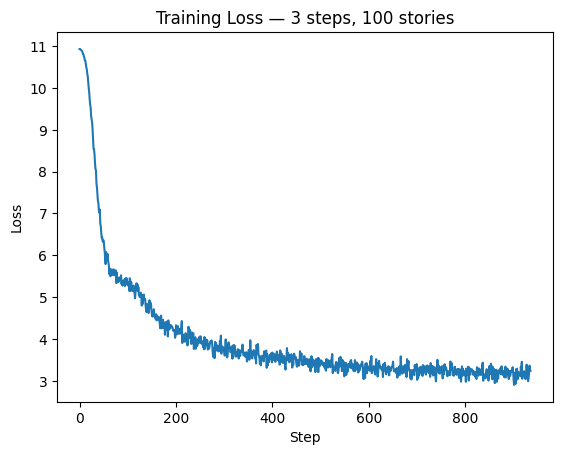

In [29]:
# plotting the training loss
import matplotlib.pyplot as plt
plt.plot(metrics_history['train_loss'])
plt.title('Training Loss — 3 steps, 100 stories')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [30]:
#save the model checkpoint
from pathlib import Path
import orbax

checkpoint_path = Path.cwd() / "small_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as d:\VS code projects\AI\MadLLM\small_checkpoint.orbax
